In [377]:
import numpy as np
from numba import njit
from hftbacktest import BUY, SELL, GTC, MARKET, HashMapMarketDepthBacktest, BacktestAsset, Recorder

@njit
def backtest_rejection_strategy(hbt, recorder):
    """
    将 TradingView 的 Rejection Detector 指标翻译为 hftbacktest 策略。
    该策略通过在 tick 数据流中构建分钟级K线来识别长下影线的“拒绝买入”信号，
    并结合止盈和止损进行交易。

    Args:
        hbt: 高频回测引擎实例。
        recorder: 用于记录数据的实例。

    Returns:
        成功完成时返回 True。
    """
    # --- 策略参数 ---
    asset_no = 0

    # K线周期（这里我们定义为1分钟）
    CANDLE_INTERVAL_NS = 1 * 60 * 1_000_000_000
    
    # 来自 TradingView 脚本的拒绝信号参数
    REJECTION_RATIO = 0.9  # 影线与总长度的最小比率
    MIN_BODY_RATIO = 0.03    # 实体与总长度的最小比率
    
    # 出场条件参数
    TAKE_PROFIT_FACTOR = 1.005  # 0.5% 止盈
    STOP_LOSS_FACTOR = 0.99    # 0.5% 止损
    
    # 策略逻辑执行的间隔
    elapsed_interval = 100_000_000  # 100ms

    # --- 订单和市场属性 ---
    lot_size = hbt.depth(asset_no).lot_size
    order_qty = lot_size
    
    # --- 状态变量 ---
    
    # 持仓状态
    entry_price = 0.0
    
    # K线构建变量
    candle_start_time = 0
    open_price = 0.0
    high_price = 0.0
    low_price = np.inf
    # close_price 将是每个时间间隔内的最后一个 mid_price

    # --- 主回测循环 ---
    while hbt.elapse(elapsed_interval) == 0:
        # Clears cancelled, filled or expired orders.
        hbt.clear_inactive_orders(0)

        # 获取当前市场深度、仓位和时间戳
        depth = hbt.depth(asset_no)
        position = hbt.position(asset_no)
        current_timestamp = hbt.current_timestamp
        
        best_bid = depth.best_bid
        best_ask = depth.best_ask
        
        # 如果市场流动性不足则跳过
        if best_bid == 0 or best_ask == 0:
            continue
            
        mid_price = (best_bid + best_ask) / 2.0
        
        # --- K线构建逻辑 ---
        
        # 初始化第一根K线
        if candle_start_time == 0:
            candle_start_time = current_timestamp
            open_price = mid_price
        
        # 检查是否进入了新的K线周期
        if current_timestamp >= candle_start_time + CANDLE_INTERVAL_NS:
            # 上一根K线已经形成，close_price 就是上一个tick的mid_price
            # 我们在这里称之为 last_mid_price 以避免混淆
            last_mid_price = mid_price # 实际上是上一个时间片的mid_price，这里为简化处理
            
            # --- 在K线收盘时应用“拒绝”信号逻辑 ---
            o = open_price
            h = high_price
            l = low_price
            c = last_mid_price # K线收盘价

            total_range = h - l
            body_size = np.abs(c - o)
            lower_wick = np.min(np.array([o, c])) - l
            
            # 初始化一个布尔值来跟踪信号
            rej_buy = False
            
            # 只有在K线有波幅时才进行计算
            if total_range > 0:
                is_long_lower_wick = (lower_wick / total_range) >= REJECTION_RATIO
                has_min_body = (body_size / total_range) >= MIN_BODY_RATIO
                
                if is_long_lower_wick and has_min_body:
                    rej_buy = True
                    # print('[rej_buy] signal at timestamp:', current_timestamp)

            # --- 入场逻辑 ---
            # 如果没有持仓并且出现了“拒绝买入”信号
            if position == 0 and rej_buy:
                hbt.submit_buy_order(asset_no, 1, best_ask, order_qty, GTC, MARKET, False)
                entry_price = best_ask  # 假设订单会以best_ask成交
                print('Entered long position at price:', entry_price, 'at timestamp:', current_timestamp)

            # --- 为新的K线重置数据 ---
            candle_start_time = current_timestamp
            open_price = mid_price
            high_price = mid_price
            low_price = mid_price
        else:
            # --- 在当前K线周期内更新数据 ---
            if mid_price > high_price:
                high_price = mid_price
            if mid_price < low_price:
                low_price = mid_price
        
        # --- 持仓管理逻辑 (每个tick都检查) ---
        is_in_position = position > 0
        if is_in_position and entry_price > 0:
            # 止盈检查
            if mid_price >= entry_price * TAKE_PROFIT_FACTOR:
                hbt.submit_sell_order(asset_no, -1, best_bid, position, GTC, MARKET, False)
                entry_price = 0.0 # 重置入场价
                print('Exited long position at price:', mid_price, 'at timestamp:', current_timestamp, '(Take Profit)')
            # 止损检查
            elif mid_price <= entry_price * STOP_LOSS_FACTOR:
                hbt.submit_sell_order(asset_no, -2, best_bid, position, GTC, MARKET, False)
                entry_price = 0.0 # 重置入场价
                print('Exited long position at price:', mid_price, 'at timestamp:', current_timestamp, '(Stop Loss)')

        # 记录当前状态用于分析
        recorder.record(hbt)
        
    return True

In [352]:
hft_data = np.load(r"D:\Project\DataAnalysis\OKX-HFT-BTC-USDT-2025-03-15.npz")['data']

In [378]:
%%time
from hftbacktest import BacktestAsset, Recorder, ROIVectorMarketDepthBacktest, HashMapMarketDepthBacktest
asset = (
    BacktestAsset()
        .data([hft_data])
        .linear_asset(1.0)
        .constant_order_latency(10_000_000, 10_000_000)
        .risk_adverse_queue_model()
        .no_partial_fill_exchange()
        .trading_value_fee_model(0.0008, 0.0010)
        .tick_size(0.1)
        .lot_size(0.001)
        .last_trades_capacity(1000000)
)

hbt = HashMapMarketDepthBacktest([asset])
recorder = Recorder(1, 5_000_000)

tick_size = 0.1
lot_size = 0.001

backtest_rejection_strategy(
    hbt, 
    recorder.recorder, 
    # elapsed_interval=1 * 1000 * 1000_000
)
_ = hbt.close()

Entered long position at price: 84276.0 at timestamp: 1741998789709000000
CPU times: total: 5.91 s
Wall time: 5.94 s


shape: (1, 11)
┌───────────┬───────────┬──────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ start     ┆ end       ┆ SR       ┆ Sortino   ┆ … ┆ DailyTurn ┆ ReturnOve ┆ ReturnOve ┆ MaxPositi │
│ ---       ┆ ---       ┆ ---      ┆ ---       ┆   ┆ over      ┆ rMDD      ┆ rTrade    ┆ onValue   │
│ datetime[ ┆ datetime[ ┆ f64      ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ μs]       ┆ μs]       ┆          ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═══════════╪═══════════╪══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 2025-03-1 ┆ 2025-03-1 ┆ -0.08734 ┆ -0.121371 ┆ … ┆ 0.008462  ┆ -0.005112 ┆ -0.000063 ┆ 84.67775  │
│ 5         ┆ 6         ┆          ┆           ┆   ┆           ┆           ┆           ┆           │
│ 00:07:00  ┆ 00:01:10  ┆          ┆           ┆   ┆           ┆           ┆           ┆           │
└───────────┴───────────┴──────────┴───────────┴───┴───────────┴───────────┴

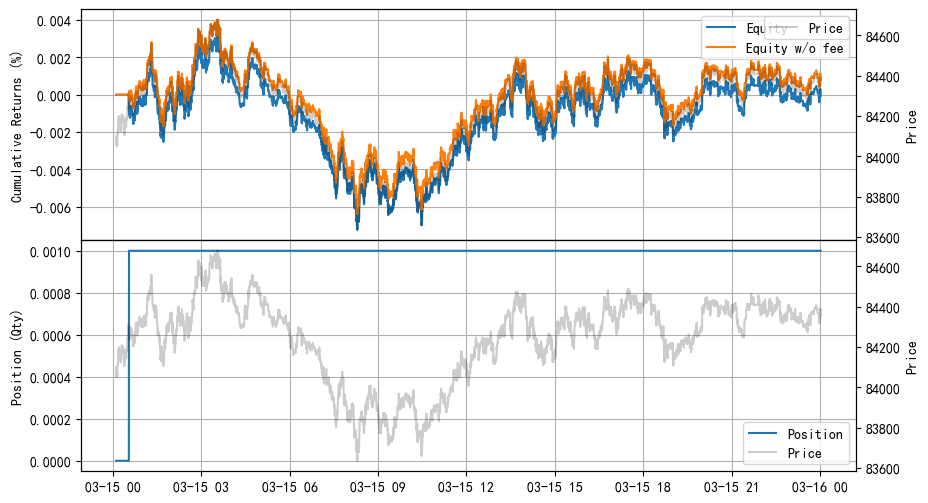

In [379]:
from hftbacktest.stats import LinearAssetRecord

stats = LinearAssetRecord(recorder.get(0)).stats(book_size=10_000)
print(stats.summary())
stats.plot()

In [380]:
stats.summary().to_dicts()

[{'start': datetime.datetime(2025, 3, 15, 0, 7),
  'end': datetime.datetime(2025, 3, 16, 0, 1, 10),
  'SR': -0.08733968112333687,
  'Sortino': -0.12137101154874483,
  'Return': -5.325999999979722e-07,
  'MaxDrawdown': 0.00010418999999999983,
  'DailyNumberOfTrades': 1.0040674026728647,
  'DailyTurnover': 0.008461878442765833,
  'ReturnOverMDD': -0.005111814953430973,
  'ReturnOverTrade': -6.319711424343493e-05,
  'MaxPositionValue': 84.67775}]